In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [2]:
import celldega as dega
import numpy as np
import pandas as pd
from anndata import AnnData
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
from spatialdata_io import xenium
import spatialdata as sd
import os
from scipy.sparse import csr_matrix
print(dega.__version__)

objc[72678]: Class GNotificationCenterDelegate is implemented in both /opt/homebrew/Cellar/glib/2.84.3/lib/libgio-2.0.0.dylib (0x30f4184b8) and /Users/jishar/anaconda3/lib/libgio-2.0.0.dylib (0x30ef0e310). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


0.13.0a9


In [3]:
from ipywidgets import Widget
Widget.close_all()

## Synthetic Data

In [4]:
# --- Create dummy test data ---
def create_test_adata():
    np.random.seed(0)
    n_cells = 10
    x = np.random.uniform(0, 100, size=n_cells)
    y = np.random.uniform(0, 100, size=n_cells)

    obs = pd.DataFrame({
        "leiden": np.random.choice(["A", "B", "C"], size=n_cells)
    }, index=[f"cell_{i}" for i in range(n_cells)])

    var = pd.DataFrame(index=["dummy_gene"])
    X = np.random.poisson(1, (n_cells, 1))

    adata = AnnData(X=X, obs=obs, var=var)
    adata.obsm["spatial"] = np.vstack([x, y]).T

    return adata

# --- Run test ---
adata = create_test_adata()
gdf_niche, gdf_hex = dega.nbhd.cluster_hex_tiles_leiden(adata, radius=15, resolution=0.5, n_neighbors=5)

# --- Show results ---
print("Niche-level clusters:")
display(gdf_niche)

print("Hex tile assignments:")
display(gdf_hex)

Calculating NBP
Niche-level clusters:


,name,geometry
0,niche_0,"MULTIPOLYGON (((64.32491 -5.47816, 64.32491 9...."
1,niche_1,"MULTIPOLYGON (((51.33453 -12.97816, 38.34415 -..."


Hex tile assignments:


,name,geometry,leiden,prop_A,prop_B,prop_C
0,hex_0,"POLYGON ((64.32491 9.52184, 51.33453 17.02184,...",1,0.000000,0.500000,0.500000
1,hex_1,"POLYGON ((90.30568 9.52184, 77.31530 17.02184,...",0,1.000000,0.000000,0.000000
2,hex_2,"POLYGON ((51.33453 32.02184, 38.34415 39.52184...",0,0.000000,0.000000,0.000000
3,hex_3,"POLYGON ((77.31530 32.02184, 64.32491 39.52184...",0,0.000000,0.000000,0.000000
4,hex_4,"POLYGON ((64.32491 54.52184, 51.33453 62.02184...",1,0.000000,1.000000,0.000000
5,hex_5,"POLYGON ((90.30568 54.52184, 77.31530 62.02184...",0,1.000000,0.000000,0.000000
6,hex_6,"POLYGON ((51.33453 77.02184, 38.34415 84.52184...",0,0.000000,0.000000,0.000000
7,hex_7,"POLYGON ((77.31530 77.02184, 64.32491 84.52184...",0,0.000000,0.000000,0.000000
8,hex_8,"POLYGON ((103.29606 77.02184, 90.30568 84.5218...",1,0.000000,1.000000,0.000000
9,hex_9,"POLYGON ((38.34415 99.52184, 25.35377 107.0218...",0,1.000000,0.000000,0.000000


<Axes: >

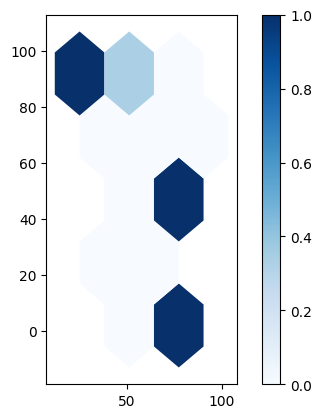

In [5]:
gdf_hex.plot(column="prop_A", cmap="Blues", legend=True)

In [7]:
gdf_hex.drop(['geometry', 'leiden'], axis=1, inplace=True)
gdf_hex.set_index('name', inplace=True)

plt.figure(figsize=(8, 6))
sns.heatmap(gdf_hex, cmap="viridis", annot=True, cbar=True)
plt.title("Cell Type Proportions per Hex")
plt.xlabel("Cell Type Proportion")
plt.ylabel("Hex")
plt.tight_layout()
plt.show()

In [12]:
gdf_clean = gdf_hex[(gdf_hex != 0).any(axis=1)]
gdf_clean = gdf_clean.loc[gdf_clean.std(axis=1) != 0]
gdf_clean = gdf_clean.replace([np.inf, -np.inf], np.nan).dropna()

In [13]:
mat = dega.clust.Matrix(
    gdf_clean,
    name='parquet'
)

mat.clust()
cgm_1 = dega.viz.Clustergram(
    matrix=mat, 
    width=500, 
    height=500
)
cgm_1

Clustergram(height=500, network_meta={'linkage': {}, 'row_attr': [], 'col_attr': [], 'row_attr_maxabs': [], 'c…

## Real Data

In [4]:
data_dir = "data/xenium_data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs"

# cluster_df = pd.read_parquet(f"{data_dir}/cell_clusters/cluster.parquet")
# cluster_df

## Make AnnData

In [5]:
# # Ingest xenium data raw output folder using spatialdata-io
# sdata = xenium(data_dir)

# # Write sdata to a zarr file
# zarr_path = f"{data_dir}.zarr"

# # Check if the zarr file already exists
# if os.path.exists(zarr_path):
#     print(f"The file {zarr_path} already exists.")
# else:
#     # If the file does not exist, write the data
#     sdata.write(zarr_path)
#     print(f"Data written to {zarr_path} successfully.")

# # Read zarr file using spatialdata
# sdata = sd.read_zarr(zarr_path)

# # Create anndata from sdata.tables['table]
# adata = sdata.tables["table"]
# adata.write_h5ad(f'{data_dir}.h5ad')

In [6]:
# # Load h5ad file
# adata = sc.read_h5ad(f'{data_dir}.h5ad')
# adata.obs.set_index('cell_id', inplace=True)

In [6]:
adata

AnnData object with n_obs × n_vars = 407124 × 5101
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

## Scanpy processing

In [7]:
# sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)
# sc.pp.filter_cells(adata, min_counts=10)
# sc.pp.filter_genes(adata, min_cells=5)

# adata.X = csr_matrix(adata.X)

# adata.layers["counts"] = adata.X

# sc.pp.normalize_total(adata, inplace=True)

# sc.pp.log1p(adata)

# sc.pp.highly_variable_genes(adata, n_top_genes=2000)
# adata = adata[:, adata.var.highly_variable].copy()

# sc.pp.pca(adata)

# sc.pp.neighbors(adata, use_rep='X_pca', n_neighbors=10)

# sc.tl.leiden(adata, resolution=1.0)

# ** use xenium default clustering, use celldega metadata

In [8]:
# adata.write_h5ad(f'with_leiden.h5ad')

In [9]:
# Convert the results to a pandas DataFrame
def get_ranked_genes_df(adata, n_genes=100):
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    dfs = []
    for group in groups:
        df = pd.DataFrame({
            'gene': result['names'][group][:n_genes],
            'logfoldchanges': result['logfoldchanges'][group][:n_genes],
            'pvals': result['pvals'][group][:n_genes],
            'pvals_adj': result['pvals_adj'][group][:n_genes],
            'scores': result['scores'][group][:n_genes],
            'cluster': group
        })
        dfs.append(df)
    return pd.concat(dfs)

## Rank and save marker genes

In [10]:
# # Run ranking (faster)
# sc.tl.rank_genes_groups(adata, groupby="leiden", method="t-test", use_raw=False, show_progress=True)

# # Save markers
# marker_df = get_ranked_genes_df(adata, n_genes=100)
# marker_df.to_csv("data/xenium_data/marker_genes_by_cluster.csv", index=False)

#### "Predicted_Cell_Types_by_Cluster.csv" has the predicted cell types for each cluster based on the top 10 marker genes, with the cluster number included in the label.

In [11]:
adata = sc.read_h5ad(f'data/xenium_data/with_leiden.h5ad')

## From chatgpt

In [12]:
pred_cell_types_df = pd.read_csv("data/xenium_data/Predicted_Cell_Types_by_Cluster.csv")
pred_cell_types_df.drop(['Unnamed: 0'], axis=1, inplace=True)
pred_cell_types_df["category"] = pred_cell_types_df["predicted_cell_type"].str.split("_").str[0]
pred_cell_types_df

,cluster,predicted_cell_type,category
0,0,Unknown_0,Unknown
1,1,Epithelial_1,Epithelial
2,2,Smooth muscle_2,Smooth muscle
3,3,Fibroblast_3,Fibroblast
4,4,Epithelial_4,Epithelial
5,5,Unknown_5,Unknown
6,6,Macrophage_6,Macrophage
7,7,Endothelial_7,Endothelial
8,8,T cell_8,T cell
9,9,Endothelial_9,Endothelial


## Cell-cluster by Hextile using NBHD module methods

In [25]:
nbp_anndata, gdf_nbhd = dega.nbhd.prepare_nbhd_for_clustering(adata, nbhd_type="HEX", radius=75)

Calculating NBP


In [26]:
# Clustering
sc.pp.normalize_total(nbp_anndata, inplace=True)
sc.pp.log1p(nbp_anndata)
sc.pp.neighbors(nbp_anndata, n_neighbors=10)
sc.tl.leiden(nbp_anndata, resolution=1)

/Users/jishar/Downloads/celldega/dega/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/Users/jishar/Downloads/celldega/dega/lib/python3.11/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [27]:
population_distribution = pd.DataFrame(
    nbp_anndata.X, index=nbp_anndata.obs_names, columns=nbp_anndata.var_names
)

In [28]:
# Add clustering and proportions to hex GeoDataFrame
gdf_nbhd = gdf_nbhd.set_index("name")
gdf_nbhd["leiden"] = nbp_anndata.obs["leiden"].values
gdf_nbhd["niche"] = [f"niche_{cluster}" for cluster in nbp_anndata.obs["leiden"].values]
gdf_nbhd = gdf_nbhd.join(population_distribution)
gdf_nbhd.reset_index(inplace=True)

# Dissolve to form niches
gdf_niche = gdf_nbhd.dissolve(by="leiden", as_index=False)
gdf_niche["name"] = [f"niche_{c}" for c in gdf_niche["leiden"]]

## Static heatmap

In [29]:
# gdf_hex.drop(['geometry', 'leiden'], axis=1, inplace=True)
# gdf_hex.set_index('name', inplace=True)

# # Convert GeoDataFrame to regular DataFrame
# df_hex = gdf_hex.copy()
# df_hex = pd.DataFrame(df_hex)

# # Plot
# fig, ax = plt.subplots(figsize=(8, 6))
# sns.heatmap(df_hex, cmap="viridis", annot=True, cbar=True, ax=ax)

# # Move row labels (y-axis ticks) to the right
# ax.yaxis.tick_right()
# ax.yaxis.set_label_position("right")

# # Make sure column labels (x-axis) stay at top
# ax.xaxis.tick_top()
# ax.xaxis.set_label_position("top")

# # Titles and labels
# ax.set_title("Cell Type Proportions per Hex", pad=40)
# ax.set_xlabel("Cell Type Proportion")
# ax.set_ylabel("Hex")

# plt.tight_layout()
# plt.show()

## Clustergram: hextile_nbhd-by-cell_population

In [30]:
gdf_nbhd_ = gdf_nbhd.drop(['geometry', 'leiden', 'niche'], axis=1)
gdf_nbhd_.set_index('name', inplace=True)

gdf_nbhd_ = gdf_nbhd_[(gdf_nbhd_ != 0).any(axis=1)]
gdf_nbhd_ = gdf_nbhd_.loc[gdf_nbhd_.std(axis=1) != 0]
# gdf_hex_ = gdf_hex_.replace([np.inf, -np.inf], np.nan).dropna()

# gdf_hex_ = gdf_hex_.replace([np.inf, -np.inf], np.nan).fillna(0)
gdf_nbhd_.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
name,,,,,,,,,,,,,,,,,,,,,
hex_25,0.000000,0.191055,0.0,0.219629,0.351398,0.034486,0.017392,0.0,0.000000,0.051293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hex_26,0.000000,0.167054,0.0,0.110542,0.484508,0.000000,0.050644,0.0,0.012903,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hex_27,0.000000,0.158224,0.0,0.133531,0.424334,0.041964,0.041964,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hex_28,0.020619,0.223144,0.0,0.099091,0.384412,0.010363,0.040822,0.0,0.010363,0.010363,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hex_29,0.154151,0.112478,0.0,0.287682,0.000000,0.000000,0.133531,0.0,0.068993,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
meta_col = pd.DataFrame(index=gdf_nbhd_.columns.tolist())
top_cols = [int(col) for col in gdf_nbhd_.sum(axis=0).sort_values(ascending=False).index]
predicted_types = pred_cell_types_df.set_index("cluster").loc[top_cols, "category"].tolist()
meta_col['category'] = predicted_types
meta_col

,category
0,Unknown
1,Smooth muscle
2,Endothelial
3,Unknown
4,Macrophage
5,Epithelial
6,Fibroblast
7,Epithelial
8,T cell
9,Smooth muscle


In [32]:
meta_row = pd.DataFrame(index=gdf_nbhd_.index.tolist())
top_rows = gdf_nbhd_.sum(axis=1).sort_values(ascending=False).index.tolist()
niches = gdf_nbhd.set_index("name").loc[top_rows, "niche"].tolist()
meta_row['niche'] = niches
meta_row

,niche
hex_25,niche_14
hex_26,niche_9
hex_27,niche_14
hex_28,niche_14
hex_29,niche_7
...,...
hex_5806,niche_13
hex_5807,niche_17
hex_5808,niche_17
hex_5809,niche_5


In [33]:
mat = dega.clust.Matrix(
    gdf_nbhd_,
    name='parquet',
    meta_col=meta_col,
    col_attr=['category'],
    meta_row=meta_row
)

mat.clust()
cgm_1 = dega.viz.Clustergram(
    matrix=mat, 
    width=500, 
    height=500
)
cgm_1

Clustergram(height=500, network_meta={'linkage': {}, 'row_attr': ['niche'], 'col_attr': ['category'], 'row_att…

## Clustergram Transposed: cell_population-by-hextile_nbhd 

In [34]:
gdf_nbhd_T = gdf_nbhd_.T

gdf_nbhd_T.index.name = "cluster"
gdf_nbhd_T.columns.name = ""

meta_row = pd.DataFrame(index=gdf_nbhd_T.index.tolist())
top_rows = [int(col) for col in gdf_nbhd_T.sum(axis=1).sort_values(ascending=False).index]
predicted_types = pred_cell_types_df.set_index("cluster").loc[top_rows, "category"].tolist()
meta_row['category'] = predicted_types

meta_col = pd.DataFrame(index=gdf_nbhd_T.columns.tolist())
top_cols = [col for col in gdf_nbhd_T.sum(axis=0).sort_values(ascending=False).index]
niches = gdf_nbhd.set_index("name").loc[top_cols, "niche"].tolist()
meta_col['niche'] = niches

In [35]:
mat = dega.clust.Matrix(
    gdf_nbhd_T,
    name='parquet',
    meta_col=meta_col,
    col_attr=['niche'],
    meta_row=meta_row
)

mat.norm(axis='row', by='zscore')
mat.clust()
cgm_1 = dega.viz.Clustergram(
    matrix=mat, 
    width=500, 
    height=500
)
cgm_1

Clustergram(height=500, network_meta={'linkage': {}, 'row_attr': ['category'], 'col_attr': ['niche'], 'row_att…

In [47]:
# mat = dega.clust.Matrix(
#     gdf_nbhd_T,
#     name='parquet',
#     meta_col=meta_col,
#     col_attr=['niche'],
#     meta_row=meta_row
# )
# mat.downsample_to(axis='col', category='niche')

## Visualize in Landscape view: Hextile NBHD

In [36]:
gdf_nbhd_LF = gdf_nbhd.copy()
gdf_nbhd_LF = gdf_nbhd_LF[['geometry','name','leiden']]
gdf_nbhd_LF.rename(columns={'leiden':'cat'}, inplace=True)

gdf_nbhd_LF.head()

,geometry,name,cat
0,"POLYGON ((3000.75848 58.89656, 2935.80657 96.3...",hex_0,0
1,"POLYGON ((3130.66229 58.89656, 3065.71038 96.3...",hex_1,0
2,"POLYGON ((3260.56610 58.89656, 3195.61419 96.3...",hex_2,0
3,"POLYGON ((3390.46991 58.89656, 3325.51800 96.3...",hex_3,0
4,"POLYGON ((3520.37372 58.89656, 3455.42181 96.3...",hex_4,0


In [40]:
import matplotlib
# Number of unique categories
categories = gdf_nbhd_LF['cat'].cat.categories
n_cats = len(categories)

# Sample evenly spaced values from a continuous colormap
cmap = matplotlib.colormaps['tab20']
colors = [matplotlib.colors.to_hex(cmap(i / n_cats)) for i in range(n_cats)]

# Map each category string to a color
cat_to_hex = dict(zip(categories, colors))

# Map category column to color hex
gdf_nbhd_LF['color'] = gdf_nbhd_LF['cat'].astype(str).map(cat_to_hex)
gdf_nbhd_LF.head()

,geometry,name,cat,geometry_pixel,color
0,"POLYGON ((3000.75848 58.89656, 2935.80657 96.3...",hex_0,0,"POLYGON ((14121.21530 277.16026, 13815.55930 4...",#1f77b4
1,"POLYGON ((3130.66229 58.89656, 3065.71038 96.3...",hex_1,0,"POLYGON ((14732.52731 277.16026, 14426.87130 4...",#1f77b4
2,"POLYGON ((3260.56610 58.89656, 3195.61419 96.3...",hex_2,0,"POLYGON ((15343.83931 277.16026, 15038.18331 4...",#1f77b4
3,"POLYGON ((3390.46991 58.89656, 3325.51800 96.3...",hex_3,0,"POLYGON ((15955.15131 277.16026, 15649.49531 4...",#1f77b4
4,"POLYGON ((3520.37372 58.89656, 3455.42181 96.3...",hex_4,0,"POLYGON ((16566.46332 277.16026, 16260.80732 4...",#1f77b4


In [42]:
gdf_nbhd_LF

,geometry,name,cat,geometry_pixel,color
0,"POLYGON ((3000.75848 58.89656, 2935.80657 96.3...",hex_0,0,"POLYGON ((14121.21530 277.16026, 13815.55930 4...",#1f77b4
1,"POLYGON ((3130.66229 58.89656, 3065.71038 96.3...",hex_1,0,"POLYGON ((14732.52731 277.16026, 14426.87130 4...",#1f77b4
2,"POLYGON ((3260.56610 58.89656, 3195.61419 96.3...",hex_2,0,"POLYGON ((15343.83931 277.16026, 15038.18331 4...",#1f77b4
3,"POLYGON ((3390.46991 58.89656, 3325.51800 96.3...",hex_3,0,"POLYGON ((15955.15131 277.16026, 15649.49531 4...",#1f77b4
4,"POLYGON ((3520.37372 58.89656, 3455.42181 96.3...",hex_4,0,"POLYGON ((16566.46332 277.16026, 16260.80732 4...",#1f77b4
...,...,...,...,...,...
5813,"POLYGON ((8002.05518 8046.39656, 7937.10328 80...",hex_5813,0,"POLYGON ((37656.72745 37865.39274, 37351.07145...",#1f77b4
5814,"POLYGON ((8131.95899 8046.39656, 8067.00709 80...",hex_5814,0,"POLYGON ((38268.03946 37865.39274, 37962.38345...",#1f77b4
5815,"POLYGON ((8261.86280 8046.39656, 8196.91090 80...",hex_5815,0,"POLYGON ((38879.35146 37865.39274, 38573.69546...",#1f77b4
5816,"POLYGON ((8391.76662 8046.39656, 8326.81471 80...",hex_5816,0,"POLYGON ((39490.66346 37865.39274, 39185.00746...",#1f77b4


In [41]:
sample = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
data_dir = f'data/xenium_data/'
path_landscape_files=f'data/landscape_files/{sample}_test'

landscape_ist = dega.viz.Landscape(
    technology="Xenium",
    base_url = f"http://localhost:{dega.viz.get_local_server()}/{path_landscape_files}",
    nbhd=gdf_nbhd_LF
)

landscape_ist

Landscape(base_url='http://localhost:53097/data/landscape_files/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs_te…

In [48]:
dega.viz.landscape_clustergram(landscape_ist, cgm_1, entity='nbhd')

## Visualize in Landscape view: Niche NBHD

In [86]:
gdf_niche_LF = gdf_niche.copy()
gdf_niche_LF = gdf_niche_LF[['geometry','name','leiden']]
gdf_niche_LF.rename(columns={'leiden':'cat'}, inplace=True)
gdf_niche_LF.head()

,geometry,name,cat
0,"MULTIPOLYGON (((662.48989 1783.89656, 662.4898...",niche_0,0
1,"MULTIPOLYGON (((5339.02707 5833.89656, 5339.02...",niche_1,1
2,"MULTIPOLYGON (((142.87464 5233.89656, 207.8265...",niche_2,2
3,"MULTIPOLYGON (((532.58608 5383.89656, 597.5379...",niche_3,3
4,"MULTIPOLYGON (((1636.76847 5571.39656, 1571.81...",niche_4,4


In [87]:
# Convert 'cat' from categorical strings like '0' → int → +1 → str again
gdf_niche_LF['cat'] = gdf_niche_LF['cat'].astype(int) + 1
gdf_niche_LF['cat'] = gdf_niche_LF['cat'].astype(str)
gdf_niche_LF['cat'] = gdf_niche_LF['cat'].astype('category')
gdf_niche_LF.head()

,geometry,name,cat
0,"MULTIPOLYGON (((662.48989 1783.89656, 662.4898...",niche_0,1
1,"MULTIPOLYGON (((5339.02707 5833.89656, 5339.02...",niche_1,2
2,"MULTIPOLYGON (((142.87464 5233.89656, 207.8265...",niche_2,3
3,"MULTIPOLYGON (((532.58608 5383.89656, 597.5379...",niche_3,4
4,"MULTIPOLYGON (((1636.76847 5571.39656, 1571.81...",niche_4,5


In [88]:
import matplotlib as mpl
import numpy as np

# Number of unique categories
categories = gdf_niche_LF['cat'].cat.categories
n_cats = len(categories)

# Sample evenly spaced values from a continuous colormap
cmap = mpl.colormaps['tab20']
colors = [mpl.colors.to_hex(cmap(i / n_cats)) for i in range(n_cats)]

# Map each category string to a color
cat_to_hex = dict(zip(categories, colors))

# Map category column to color hex
gdf_niche_LF['color'] = gdf_niche_LF['cat'].astype(str).map(cat_to_hex)
gdf_niche_LF.head()

,geometry,name,cat,color
0,"MULTIPOLYGON (((662.48989 1783.89656, 662.4898...",niche_0,1,#1f77b4
1,"MULTIPOLYGON (((5339.02707 5833.89656, 5339.02...",niche_1,2,#8c564b
2,"MULTIPOLYGON (((142.87464 5233.89656, 207.8265...",niche_2,3,#f7b6d2
3,"MULTIPOLYGON (((532.58608 5383.89656, 597.5379...",niche_3,4,#7f7f7f
4,"MULTIPOLYGON (((1636.76847 5571.39656, 1571.81...",niche_4,5,#c7c7c7


In [89]:
sample = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
data_dir = f'data/xenium_data/'
path_landscape_files=f'data/landscape_files/{sample}_test'

landscape_ist = dega.viz.Landscape(
    technology="Xenium",
    base_url = f"http://localhost:{dega.viz.get_local_server()}/{path_landscape_files}",
    nbhd=gdf_niche_LF
)

landscape_ist

Landscape(base_url='http://localhost:49954/data/landscape_files/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs_te…

## Clustergram: niche_nbhd-by-cell_population

In [24]:
# Step 1: Drop unwanted columns and set index
gdf_niche_ = gdf_niche.drop(['geometry', 'leiden'], axis=1)
gdf_niche_.set_index('name', inplace=True)

# Step 2: Convert everything to numeric (coerce strings to NaN)
gdf_niche_ = gdf_niche_.apply(pd.to_numeric, errors='coerce')

# Step 3: Replace inf/-inf → NaN, then fill NaNs with 0 (or drop if preferred)
gdf_niche_ = gdf_niche_.replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 4: Drop rows/cols with all zeros or no variance
gdf_niche_ = gdf_niche_[(gdf_niche_ != 0).any(axis=1)]
gdf_niche_ = gdf_niche_.loc[gdf_niche_.std(axis=1) != 0]
gdf_niche_ = gdf_niche_.loc[:, gdf_niche_.std(axis=0) != 0]

# Final sanity check
assert np.isfinite(gdf_niche_.values).all(), "Matrix still contains non-finite values!"

In [25]:
meta_col = pd.DataFrame(index=gdf_niche_.columns.tolist())
top_cols = [int(col) for col in gdf_niche_.sum(axis=0).sort_values(ascending=False).index]
predicted_types = pred_cell_types_df.set_index("cluster").loc[top_cols, "category"].tolist()
meta_col['category'] = predicted_types
meta_col

,category
0,Unknown
1,Epithelial
2,Unknown
3,Endothelial
4,Macrophage
5,Fibroblast
6,Epithelial
7,Smooth muscle
8,T cell
9,T cell


In [26]:
mat = dega.clust.Matrix(
    gdf_niche_,
    name='parquet',
    meta_col=meta_col,
    col_attr=['category'],
)

mat.clust()
cgm_2 = dega.viz.Clustergram(
    matrix=mat, 
    width=500, 
    height=500
)
cgm_2

Clustergram(height=500, network_meta={'linkage': {}, 'row_attr': [], 'col_attr': ['category'], 'row_attr_maxab…